# Numerical exhibits

Saved outputs show the tables and figures for *Residual Learning in Empirical Asset Pricing*. Tables use DataFrames and figures use Matplotlib. Reading these saved outputs requires no numerical caches. Rerunning the cells requires local numerical inputs and caches, which are excluded from Git; computation runs on a CPU.

See [the companion guide](README.md) for input requirements and recomputation, and [the main README](../../readme.md) for training, GPU time and disk-space estimates. Once the required local inputs and reference caches are available, run `uv run python -m utils.paper_source --all --verify` from the repository root to recompute estimates and compare them with those caches.


In [1]:
from pathlib import Path
import os
import sys
import importlib.metadata as metadata
import pandas as pd
from IPython.display import display, Markdown

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "utils/paper_source").is_dir() and (path / "main.py").is_file())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils.paper_source import available, table, styled_table, figure
from utils.paper_source.preview import NOTES


Shallow = depths 1–5; Medium = 6–10; Deep = 11–20. Forecast origins are January 1987–November 2023; realized returns are February 1987–December 2023. Tables retain full-precision values through `table(name, raw=True)`. Significance markers *, **, *** denote 10%, 5%, 1% where the exhibit note specifies a test. Computation and display need no GPU. Saved reference outputs can be inspected without licensed individual-stock data. Rerunning the cells requires the local inputs and caches described in the companion guide.

## Empirical design

The result uses the reference design and numerical inputs described in the companion guide.

In [2]:
display(styled_table("ExperimentalDesignGrid"))

## Annually expanding training window

The result uses the reference design and numerical inputs described in the companion guide.

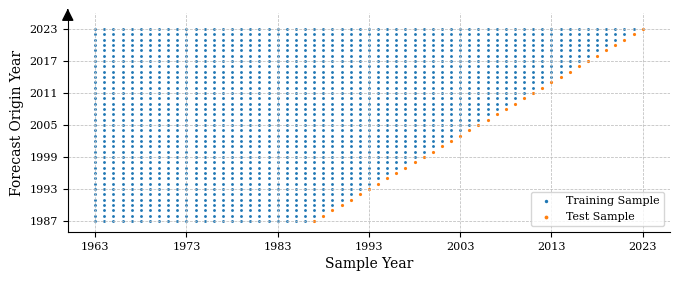

In [3]:
display(figure("RollingTrainTestSplit"))

## Long-short portfolio performance

Mean, SD, FF5 alpha and turnover are monthly percentages; SR is annualized. Model levels average available noncollapsed specifications. Delta SR uses matched specifications, so it need not equal the difference of displayed model-family means. FF5 stars use Newey–West (12 lags); delta SR stars use a studentized circular block bootstrap (12-month blocks, 1,000 draws).

In [4]:
display(styled_table("FinalBaselinePerformance"))

## Deep minus shallow Sharpe ratios

Within each model, equal-weighted mean deep SR minus mean shallow SR. Available specifications differ by model. Two-sided studentized circular block bootstrap, 12-month blocks, 1,000 draws.

In [5]:
display(styled_table("DepthGroupSharpeContrasts"))

,Deep - Shallow SR,t,p,Shallow Cells,Deep Cells,Months
Model,,,,,,
NN,-0.11**,-2.61,0.02,14,19,443
ResNet,-0.02,-0.72,0.51,14,40,443
NN+,-0.94***,-7.29,0.00,14,40,443
ResNet+,0.15**,2.08,0.04,14,40,443


## Residual minus feedforward Sharpe ratios

The result uses the reference design and numerical inputs described in the companion guide.

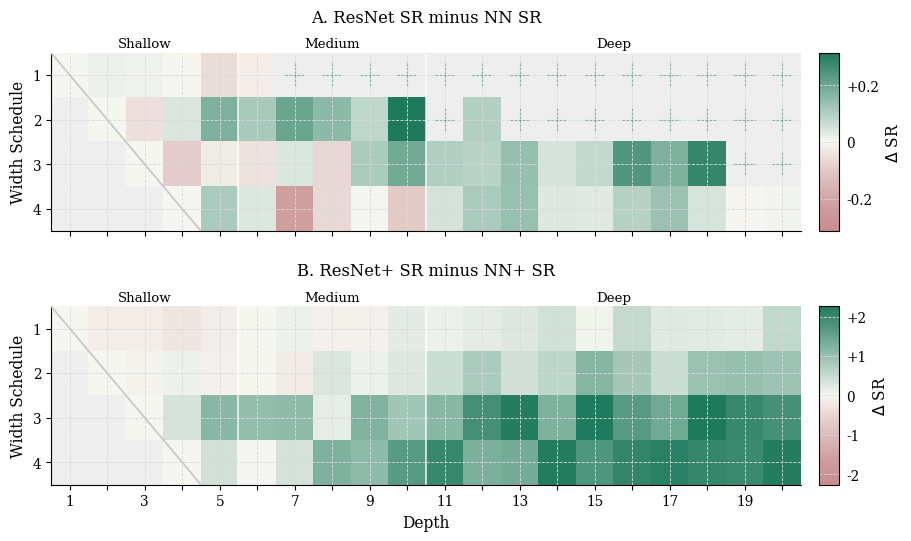

In [6]:
display(figure("SpecificationDeltaSRHeatmaps"))

## Forecast-decile return and volatility profiles

Monthly mean returns and volatility are in percent; SR is annualized. Statistics are computed per specification, then averaged equally across completed specifications shared by both models in each comparison. Constant forecasts enter this descriptive figure using seeded tie splitting.

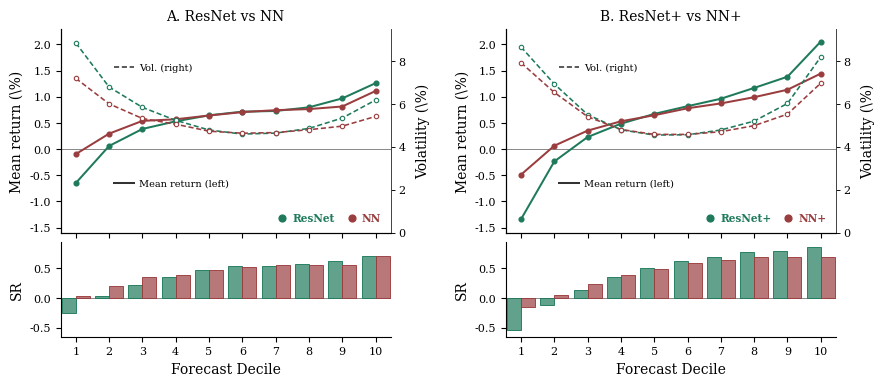

In [7]:
display(figure("DecileMonotonicitySelected"))

## Decile portfolio performance

Fcst, mean and SD are monthly percentages; SR is annualized. Statistics are computed per specification before equal-weighted depth aggregation. Each model uses its own completed nonconstant-forecast specifications, matching its baseline performance sample.

### NN

In [8]:
display(styled_table("FullDecileMonotonicity", model="NN"))

### ResNet

In [9]:
display(styled_table("FullDecileMonotonicity", model="ResNet"))

### NN+

In [10]:
display(styled_table("FullDecileMonotonicity", model="NN+"))

### ResNet+

In [11]:
display(styled_table("FullDecileMonotonicity", model="ResNet+"))

## Forecast preservation and refinement

P is the unchanged-pair share; C is revision accuracy among changed pairs, in percent; V is revision economic value in monthly basis points, not a portfolio return. Average each specification over months, then equally across specifications. Difference is residual minus feedforward; its eligible specification sets can differ. Newey–West (12 lags); no stars on model-level P.

In [12]:
display(styled_table("ForecastRefinement"))

## Preservation and revision accuracy by depth

The result uses the reference design and numerical inputs described in the companion guide.

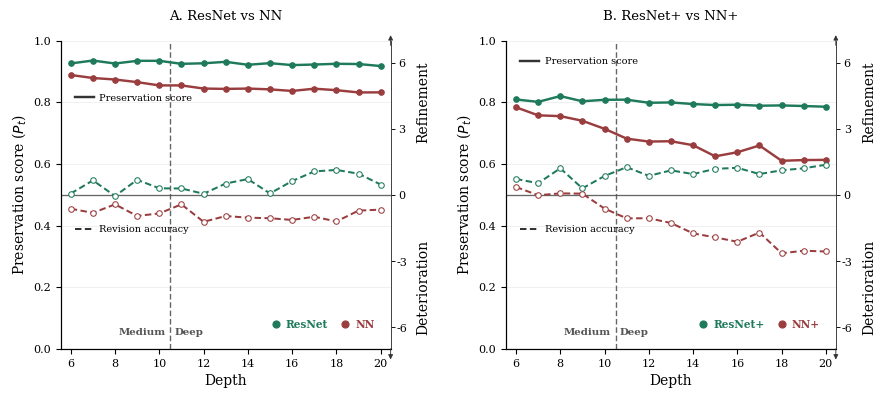

In [13]:
display(figure("ForecastRankPreservationAndRefinementByDepth"))

## Forecast preservation and revision losses by theme

Original minus theme-zeroed forecasts, removing the same theme from shallow and deep models. Delta P is unscaled; delta C is in percentage points; delta V is in monthly basis points. Stars use Holm-adjusted p-values across 13 themes. These are input-sensitivity comparisons.

### NN

In [14]:
display(styled_table("ThemePairwiseLosses", model="NN"))

### ResNet

In [15]:
display(styled_table("ThemePairwiseLosses", model="ResNet"))

### NN+

In [16]:
display(styled_table("ThemePairwiseLosses", model="NN+"))

### ResNet+

In [17]:
display(styled_table("ThemePairwiseLosses", model="ResNet+"))

## Robustness to size exclusions

Annualized value-weighted long-short SR; exclude the smallest or largest 20 percent by market capitalization. Each comparison uses its matched noncollapsed specifications. Stars use the same 12-month-block Sharpe bootstrap.

In [18]:
display(styled_table("SizeExclusionRobustness"))

## Performance after transaction costs

Annualized net Sharpe ratios at one-way costs of 0, 10 and 50 bps. Monthly gross long-short turnover is in percent. Comparisons use matched noncollapsed specifications; bootstrap stars test residual minus feedforward SR.

In [19]:
display(styled_table("TransactionCostAdjustedPerformance"))

## Performance across market states

Monthly value-weighted long-short returns, in percent, averaged across matched specifications before time aggregation. Newey–West inference is omitted for intervals shorter than 13 months. Periods use realized-return months.

In [20]:
display(styled_table("MarketStateRobustness"))

,,,Months,Residual mean (%),Feedforward mean (%),Δ Mean (%),t
Comparison,Period,State,,,,,
ResNet vs NN,1987:02–1990:07,Expansion,42,3.26,2.44,0.82***,3.28
ResNet+ vs NN+,1987:02–1990:07,Expansion,42,2.90,0.51,2.39***,10.17
ResNet vs NN,1990:08–1991:03,Recession,8,4.52,3.86,0.66,—
ResNet+ vs NN+,1990:08–1991:03,Recession,8,5.59,1.22,4.37,—
ResNet vs NN,1991:04–2001:03,Expansion,120,2.23,2.21,0.03,0.14
ResNet+ vs NN+,1991:04–2001:03,Expansion,120,5.62,2.73,2.89***,16.00
ResNet vs NN,2001:04–2001:11,Recession,8,5.52,4.38,1.14,—
ResNet+ vs NN+,2001:04–2001:11,Recession,8,7.80,4.10,3.71,—
ResNet vs NN,2001:12–2007:12,Expansion,73,1.60,1.35,0.25*,1.66


## Predictors for one-month-ahead excess returns

153 firm characteristics and eight macro predictors. Firm characteristics are median-imputed by month and rank-normalized; macro predictors enter in levels.

In [22]:
display(styled_table("PredictorList"))

,Acronym,Description,Block,Source,Frequency
No.,,,,,
1,niq_su,Standardized earnings surprise,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
2,ret_6_1,Price momentum t-6 to t-1,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
3,ret_12_1,Price momentum t-12 to t-1,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
4,saleq_su,Standardized revenue surprise,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
5,tax_gr1a,Tax expense surprise,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
6,ni_inc8q,Number of consecutive quarters with earnings increases,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
7,prc_highprc_252d,Current price to high price over last year,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
8,resff3_6_1,Residual momentum t-6 to t-1,Firm characteristic,JKP stock-characteristic panel,Monthly aligned
9,resff3_12_1,Residual momentum t-12 to t-1,Firm characteristic,JKP stock-characteristic panel,Monthly aligned


## Shallow and deep pairwise ranking values

P is unscaled; C is in percent; shallow and deep ranking values are monthly basis points over all pairs. Deep minus shallow ranking value equals revision economic value. Newey–West standard errors use 12 lags.

In [23]:
display(styled_table("AppendixForecastRankingValues"))

## Shallow and deep ranking-value losses by theme

Delta P compares unchanged-pair shares over all stock pairs. Delta C compares revision accuracy calculated on each original or theme-zeroed forecast comparison's own changed pairs. Delta V(S) and delta V(D) are original minus theme-zeroed shallow and deep ranking values over all pairs, in monthly basis points. Their difference reconciles to the main theme revision-value loss. Stars use Holm adjustment.

### NN

In [24]:
display(styled_table("AppendixThemeValueLosses", model="NN"))

### ResNet

In [25]:
display(styled_table("AppendixThemeValueLosses", model="ResNet"))

### NN+

In [26]:
display(styled_table("AppendixThemeValueLosses", model="NN+"))

### ResNet+

In [27]:
display(styled_table("AppendixThemeValueLosses", model="ResNet+"))

## Forecast collapse diagnostics

NN and ResNet at width schedule 1, depths 3 and 7. Constant-forecast months are a ranking failure diagnostic.

In [28]:
display(styled_table("S1D7DiagnosticSummary"))

## Equal-weighted portfolio robustness

Matched equal-weighted long-short portfolios. SR is annualized; alpha, R2 and turnover differences are in percentage points. SR stars use the block bootstrap.

In [30]:
display(styled_table("EqualWeightedRobustness"))

## NN+ and ResNet+ by width and depth

Unrounded underlying values are available through table(..., raw=True). Return, alpha, drawdown and turnover measures are percentages; SR is annualized. Missing specifications are not imputed.

These reference tables retain historical FF5 alpha values. New evaluations use realization-month factors without an extra RF subtraction; recompute alphas before comparing runs.

### NN+

In [31]:
display(styled_table("PairedSpecificationDepthProfile", model="NN+"))

### ResNet+

In [32]:
display(styled_table("PairedSpecificationDepthProfile", model="ResNet+"))

## NN and ResNet by width and depth

Constant forecasts are excluded from this performance profile. Missing specifications are not imputed; use the collapse diagnostic for failed rankings.

These reference tables retain historical FF5 alpha values. New evaluations use realization-month factors without an extra RF subtraction; recompute alphas before comparing runs.

### NN

In [33]:
display(styled_table("ResNetVsNNDepthProfile", model="NN"))

### ResNet

In [34]:
display(styled_table("ResNetVsNNDepthProfile", model="ResNet"))

## Network parameter counts

The result uses the reference design and numerical inputs described in the companion guide.

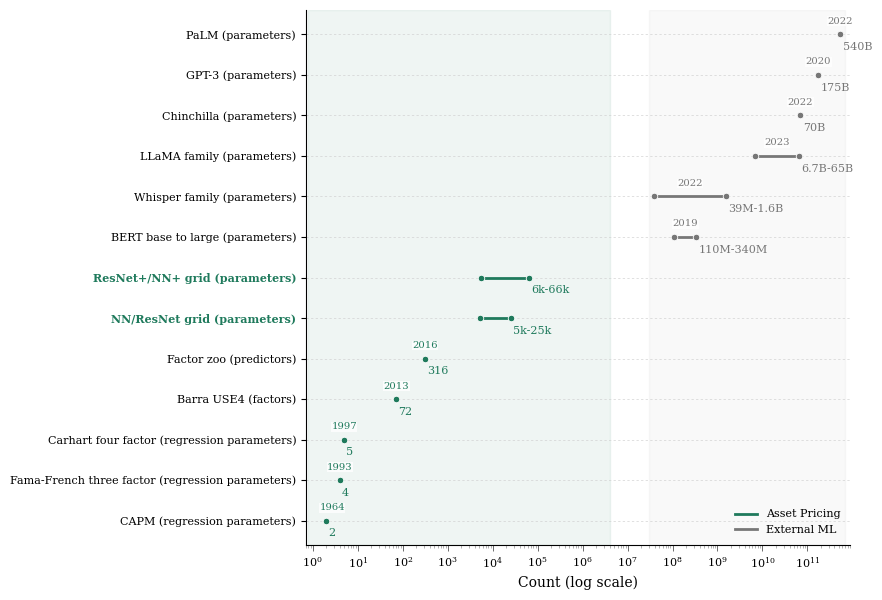

In [35]:
display(figure("ParameterScaleGap"))

## Verification

Saved cell outputs can be read in a clean checkout. Rerunning the notebook loads local numerical caches and regenerates figures. The separate CPU verification command recomputes estimates from the documented inputs and compares them with locally available reference caches. Stock-level forecast diagnostics require their upstream source summaries, as detailed in README.md.


In [ ]:
assert len(available()) == 21
print("21 numerical exhibits are registered; full recomputation: python -m utils.paper_source --all --verify")

21 numerical exhibits are registered; full recomputation: python -m utils.paper_source --all --verify
